In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid", palette="husl")

In [50]:
# Load VLM-SAM experiment results (partial)
sam = pd.read_csv("results_partial.csv")
lm = pd.read_csv("lm_eec_pairs_from_vlm460850.csv")


In [51]:
sam.head()

,take_uid,object_name,src_camera,dest_camera,frame,experiment,vlm_model,vlm_output,iou,ba,ca,le,obj_rel_area,obj_dist_center,obj_size_cat,obj_is_peripheral
0,0efd9fc1-0f49-403d-9252-93f119a3ea3c,stainless_spoon_0,aria01_214-1,gp04,10260,EXP-A,qwen3-vl:235b-cloud,red cup,0.039062,0.999828,0.0,0.000345,0.000015,0.272249,small,False
1,0efd9fc1-0f49-403d-9252-93f119a3ea3c,stainless_spoon_0,aria01_214-1,gp04,10260,EXP-B,qwen3-vl:235b-cloud,red berries,0.000000,0.000000,0.0,1.000000,0.000015,0.272249,small,False
2,0efd9fc1-0f49-403d-9252-93f119a3ea3c,stainless_spoon_0,aria01_214-1,gp04,10260,EXP-C,qwen3-vl:235b-cloud,white mug,0.000000,0.000000,0.0,1.000000,0.000015,0.272249,small,False
3,39feb026-bcf8-4a61-89ad-9f5566c2c7bf,chopped cucumber_0,aria01_214-1,cam04,4230,EXP-A,qwen3-vl:235b-cloud,red pepper,0.000000,0.000000,0.0,1.000000,0.003388,0.241821,small,False
4,39feb026-bcf8-4a61-89ad-9f5566c2c7bf,chopped cucumber_0,aria01_214-1,cam04,4230,EXP-B,qwen3-vl:235b-cloud,green cucumbers,0.000000,0.000000,0.0,1.000000,0.003388,0.241821,small,False


In [52]:
sam['vlm_output'].head(50)

0                  red cup
1              red berries
2                white mug
3               red pepper
4          green cucumbers
5             red tomatoes
6         orange container
7           blue container
8           blue container
9               orange pen
10             blue marker
11           orange marker
12       red cutting board
13     white cutting_board
14     white cutting board
15          orange carrots
16              white bowl
17              white bowl
18              red pepper
19              red tomato
20        white chopsticks
21             white onion
22          blue container
23         purple eggplant
24    orange cutting board
25               white lid
26               white lid
27            orange plate
28             yellow bowl
29              white bowl
30            green pepper
31              red bottle
32              red bottle
33           brown package
34            silver knife
35             red package
36            red tomatoes
3

## 1. Data overview and variable descriptions

**Dataset:** VLM-SAM experiment results (partial). Each row is one (take, object, frame, experiment) with metrics from matching VLM output to ground-truth.

 **Metrics (reminder):** VLM text prompts are used to condition SAM; we match the best SAM mask to the ground-truth mask per frame.  
 
 - **IoU** (Intersection over Union):  
   $$
   \mathrm{IoU} = \frac{|\text{Prediction} \cap \text{GT}|}{|\text{Prediction} \cup \text{GT}|}
   $$
   Where $|\cdot|$ denotes the number of pixels in the mask, and "GT" is the ground-truth mask.
 
 - **BA** (Balanced Accuracy, pixel-wise):  
   $$
   \mathrm{BA} = \frac{1}{2} \left( \frac{\text{TP}}{\text{TP} + \text{FN}} + \frac{\text{TN}}{\text{TN} + \text{FP}} \right)
   $$
   Where TP: true positives, TN: true negatives, FP: false positives, FN: false negatives, computed pixel-wise.
 
 - **CA** (Contour Accuracy):  
   $$
   \mathrm{CA} = \frac{|\partial\text{Prediction} \cap \partial\text{GT}|}{|\partial\text{Prediction} \cup \partial\text{GT}|}
   $$
   Where $\partial$ denotes the boundary (contour) pixels of the mask.
 
  - **LE** (Location Error):  
    $$
    \mathrm{LE} = \frac{|\text{Prediction} \neq \text{GT}|}{N}
    $$
    Where $|\text{Prediction} \neq \text{GT}|$ is the number of pixels predicted incorrectly compared to GT, and $N$ is the total number of pixels. ($\mathrm{LE}=0$ is perfect overlap, $\mathrm{LE}=1$ is no match.)

In [53]:
# Shape and missing values
print("Shape:", sam.shape)
print("\nMissing values:\n", sam.isna().sum())
# Variable types and short descriptions
desc = pd.DataFrame({
    "variable": sam.columns,
    "dtype": sam.dtypes.astype(str),
    "description": [
        "Take ID", "Object name", "Source camera", "Dest camera", "Frame index",
        "Experiment (A/B/C)", "VLM model", "VLM predicted label",
        "IoU (overlap)", "Box accuracy", "Class accuracy", "Location error (1 = wrong)",
        "Object relative area in image", "Object distance from center",
        "Object size category (small/medium/large)", "Object in periphery"
    ]
})
display(desc)

Shape: (756, 16)

Missing values:
 take_uid             0
object_name          0
src_camera           0
dest_camera          0
frame                0
experiment           0
vlm_model            0
vlm_output           0
iou                  0
ba                   0
ca                   0
le                   0
obj_rel_area         0
obj_dist_center      0
obj_size_cat         0
obj_is_peripheral    0
dtype: int64


,variable,dtype,description
take_uid,take_uid,str,Take ID
object_name,object_name,str,Object name
src_camera,src_camera,str,Source camera
dest_camera,dest_camera,str,Dest camera
frame,frame,int64,Frame index
experiment,experiment,str,Experiment (A/B/C)
vlm_model,vlm_model,str,VLM model
vlm_output,vlm_output,str,VLM predicted label
iou,iou,float64,IoU (overlap)
ba,ba,float64,Box accuracy


In [54]:
# Summary statistics for numerical variables
sam.describe().round(4)

,frame,iou,ba,ca,le,obj_rel_area,obj_dist_center
count,756.0000,756.0000,756.0000,756.0000,756.0000,756.0000,756.0000
mean,9219.8810,0.1532,0.2044,0.0448,0.7656,0.0051,0.2763
std,7975.9032,0.3284,0.3778,0.1035,0.4228,0.0110,0.1492
min,0.0000,0.0000,0.0000,0.0000,0.0001,0.0000,0.0320
25%,3052.5000,0.0000,0.0000,0.0000,1.0000,0.0005,0.1616
50%,6810.0000,0.0000,0.0000,0.0000,1.0000,0.0016,0.2603
75%,13335.0000,0.0000,0.0000,0.0000,1.0000,0.0044,0.3639
max,33960.0000,0.9792,0.9998,0.4679,1.0000,0.0902,0.7459


## 2. Distribution of variables

**Story:** Most metric values are concentrated at 0 (no match); a tail of higher IoU/BA/CA and lower LE indicates successful matches. Object size is mostly *small*; spatial features (area, distance) are right-skewed.

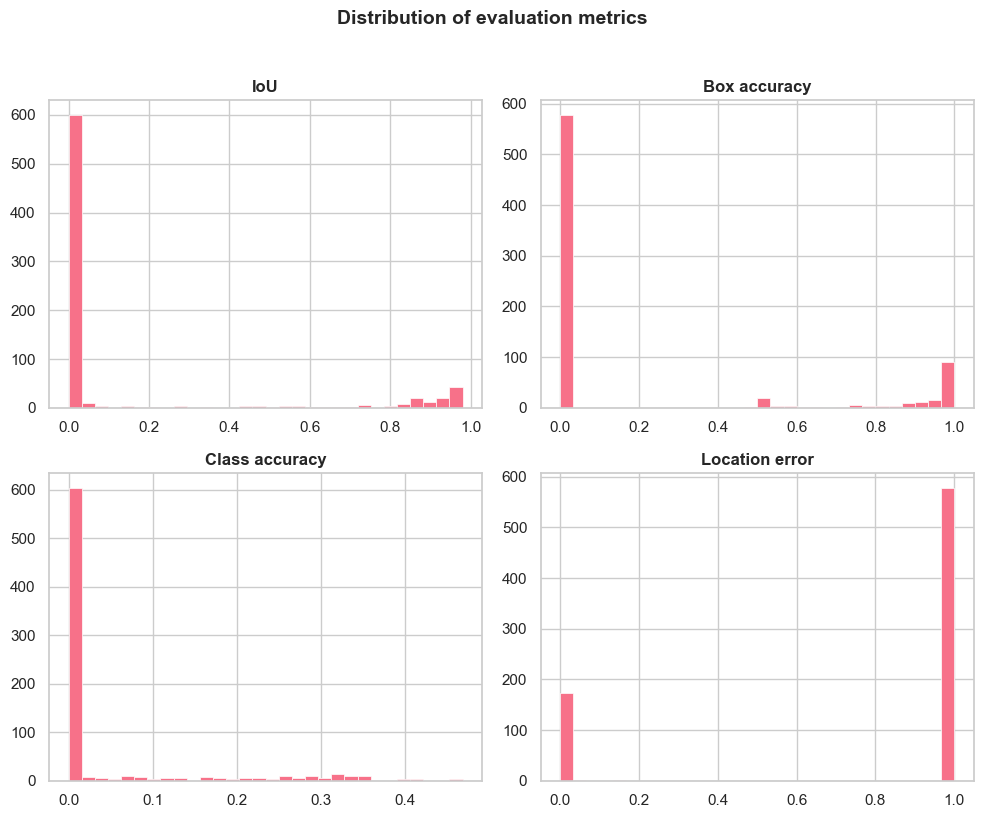

In [55]:
# Metrics: IoU, BA, CA, LE
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
metrics = ["iou", "ba", "ca", "le"]
labels = ["IoU", "Box accuracy", "Class accuracy", "Location error"]
for ax, m, lbl in zip(axes.flat, metrics, labels):
    sam[m].hist(ax=ax, bins=30, edgecolor="white", linewidth=0.5)
    ax.set_title(lbl, fontweight="bold")
    ax.set_xlabel("")
fig.suptitle("Distribution of evaluation metrics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

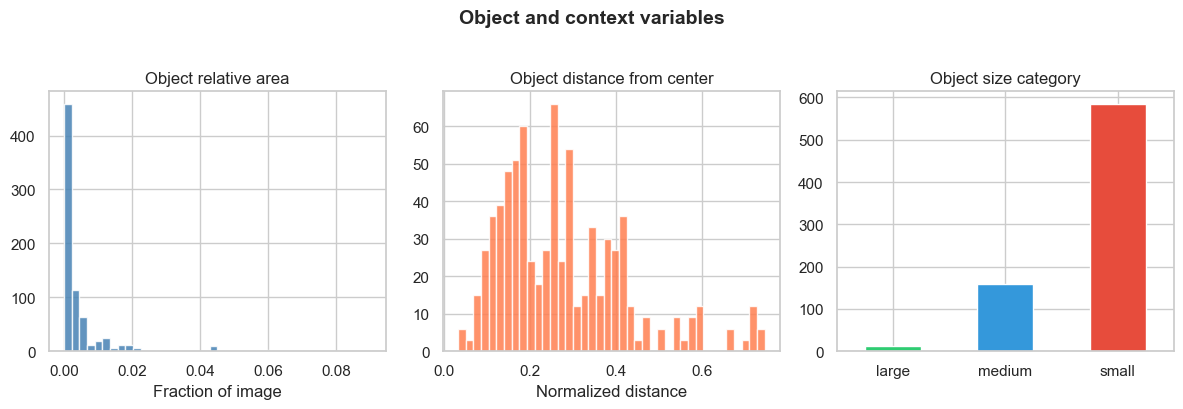

In [56]:
# Object characteristics and categorical variables
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# obj_rel_area
axes[0].hist(sam["obj_rel_area"], bins=40, edgecolor="white", color="steelblue", alpha=0.85)
axes[0].set_title("Object relative area")
axes[0].set_xlabel("Fraction of image")
# obj_dist_center
axes[1].hist(sam["obj_dist_center"], bins=40, edgecolor="white", color="coral", alpha=0.85)
axes[1].set_title("Object distance from center")
axes[1].set_xlabel("Normalized distance")
# obj_size_cat
sam["obj_size_cat"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="white")
axes[2].set_title("Object size category")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=0)
plt.suptitle("Object and context variables", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

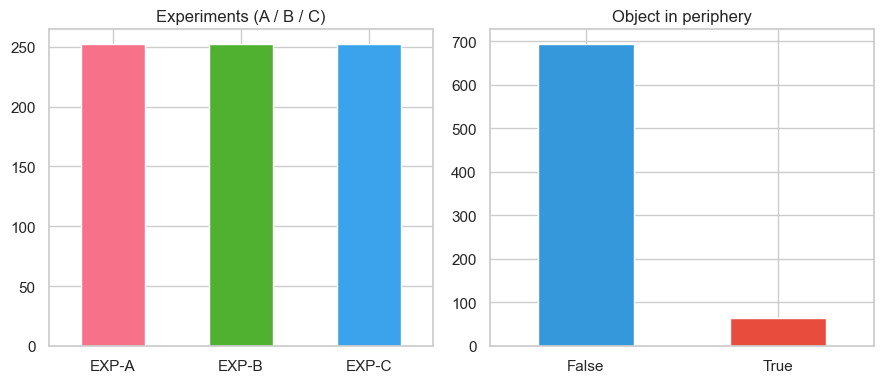

In [57]:
# Experiment and periphery
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sam["experiment"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=sns.color_palette("husl", 3), edgecolor="white")
axes[0].set_title("Experiments (A / B / C)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
sam["obj_is_peripheral"].value_counts().plot(kind="bar", ax=axes[1], color=["#3498db", "#e74c3c"], edgecolor="white")
axes[1].set_title("Object in periphery")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 3. Correlation among numerical variables

**Story:** Metrics (IoU, BA, CA, LE) are strongly related: higher overlap/accuracy goes with lower location error. Object area and distance-from-center show how object size and position relate to each other and to performance.

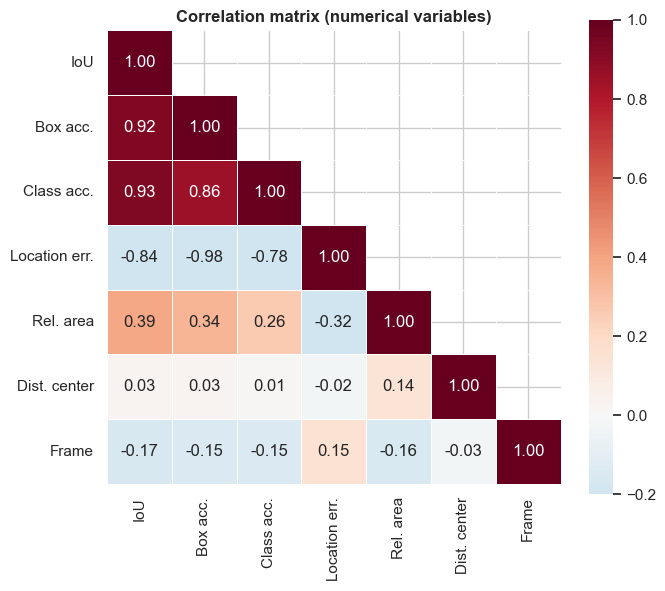

In [58]:
# Numerical columns only
num_cols = ["iou", "ba", "ca", "le", "obj_rel_area", "obj_dist_center", "frame"]
corr = sam[num_cols].corr()
# Clean labels for plot
labels = ["IoU", "Box acc.", "Class acc.", "Location err.", "Rel. area", "Dist. center", "Frame"]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only for less clutter
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            xticklabels=labels, yticklabels=labels, square=True, linewidths=0.5,
            vmin=-0.2, vmax=1)
ax.set_title("Correlation matrix (numerical variables)", fontweight="bold")
plt.tight_layout()
plt.show()

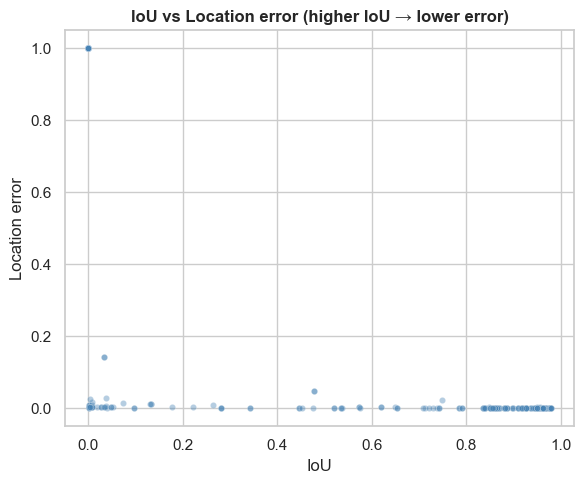

In [59]:
# Key relationship: IoU vs Location error (inverse)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sam["iou"], sam["le"], alpha=0.4, s=20, c="steelblue", edgecolors="white", linewidth=0.3)
ax.set_xlabel("IoU")
ax.set_ylabel("Location error")
ax.set_title("IoU vs Location error (higher IoU → lower error)", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Average metrics by object size (obj_size_cat)

**Story:** Does performance depend on object size? We stratify by *small / medium / large* and compare mean IoU, BA, CA, and LE. Clear bar charts make it easy to see if larger objects get better or worse matching.

In [60]:
# Mean metrics by obj_size_cat (ordered: small → medium → large)
size_order = ["small", "medium", "large"]
metrics = ["iou", "ba", "ca", "le"]
counts = sam.groupby("obj_size_cat", observed=True).size().reindex(size_order)
means_by_size = sam.groupby("obj_size_cat", observed=True)[metrics].mean().reindex(size_order)
means_by_size.index = means_by_size.index.str.capitalize()
means_by_size.columns = ["IoU", "Box accuracy", "Class accuracy", "Location error"]
print("Sample size per stratum:")
print(counts)
display(means_by_size.round(4))

Sample size per stratum:
obj_size_cat
small     585
medium    159
large      12
dtype: int64


,IoU,Box accuracy,Class accuracy,Location error
obj_size_cat,,,,
Small,0.0890,0.1376,0.0285,0.8379
Medium,0.3539,0.4136,0.0989,0.5376
Large,0.6245,0.6880,0.1191,0.2608


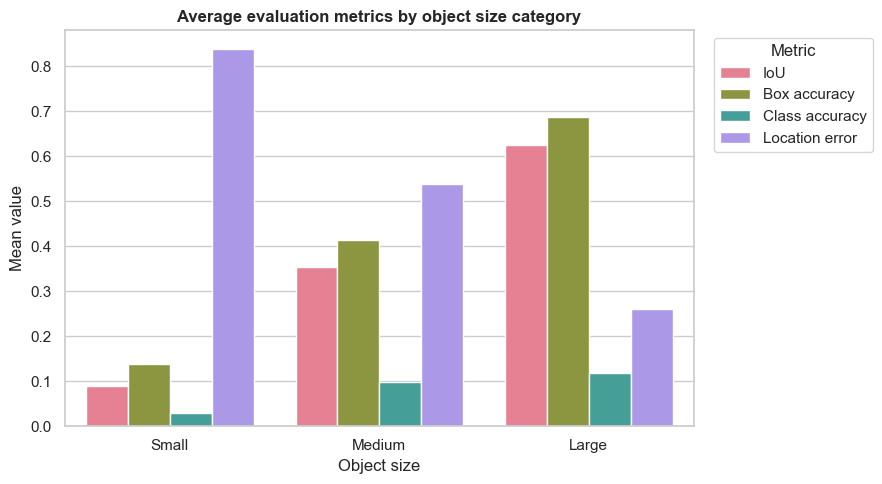

In [61]:
# Bar plot: mean metrics by object size (presentation-ready)
plot_df = means_by_size.reset_index().melt(id_vars="obj_size_cat", var_name="metric", value_name="mean_value")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_df, x="obj_size_cat", y="mean_value", hue="metric", palette="husl", edgecolor="white")
ax.set_xlabel("Object size")
ax.set_ylabel("Mean value")
ax.set_title("Average evaluation metrics by object size category", fontweight="bold")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

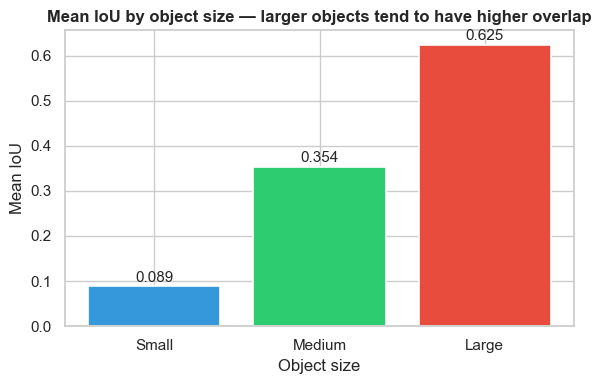

In [62]:
# Single metric focus: mean IoU by object size (clear one-message slide)
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#3498db", "#2ecc71", "#e74c3c"]
bars = ax.bar(means_by_size.index, means_by_size["IoU"], color=colors, edgecolor="white", linewidth=1.2)
ax.set_xlabel("Object size")
ax.set_ylabel("Mean IoU")
ax.set_title("Mean IoU by object size — larger objects tend to have higher overlap", fontweight="bold")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Performance metrics by experiment type

Compare mean IoU, BA, CA, and location error across experiments (EXP-A, EXP-B, EXP-C) to see which setup performs best.

In [63]:
# Mean metrics by experiment (ordered A → B → C)
metrics = ["iou", "ba", "ca", "le"]
exp_order = ["EXP-A", "EXP-B", "EXP-C"]
means_by_exp = sam.groupby("experiment", observed=True)[metrics].mean().reindex(exp_order)
means_by_exp.columns = ["IoU", "Box accuracy", "Class accuracy", "Location error"]
display(means_by_exp.round(4))

,IoU,Box accuracy,Class accuracy,Location error
experiment,,,,
EXP-A,0.0776,0.1222,0.0231,0.8503
EXP-B,0.2017,0.2498,0.0584,0.7227
EXP-C,0.1802,0.2412,0.0528,0.7236


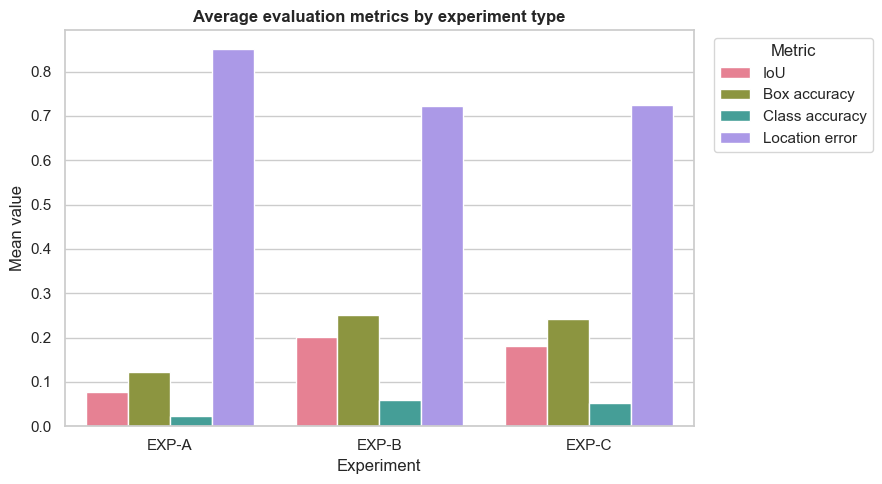

In [64]:
# Bar plot: mean metrics by experiment (presentation-ready)
plot_exp = means_by_exp.reset_index().melt(id_vars="experiment", var_name="metric", value_name="mean_value")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_exp, x="experiment", y="mean_value", hue="metric", palette="husl", edgecolor="white")
ax.set_xlabel("Experiment")
ax.set_ylabel("Mean value")
ax.set_title("Average evaluation metrics by experiment type", fontweight="bold")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

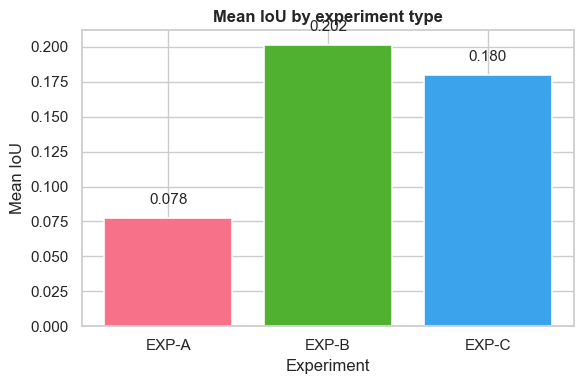

In [65]:
# Single-message: mean IoU by experiment
fig, ax = plt.subplots(figsize=(6, 4))
colors_exp = sns.color_palette("husl", 3)
bars = ax.bar(means_by_exp.index, means_by_exp["IoU"], color=colors_exp, edgecolor="white", linewidth=1.2)
ax.set_xlabel("Experiment")
ax.set_ylabel("Mean IoU")
ax.set_title("Mean IoU by experiment type", fontweight="bold")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

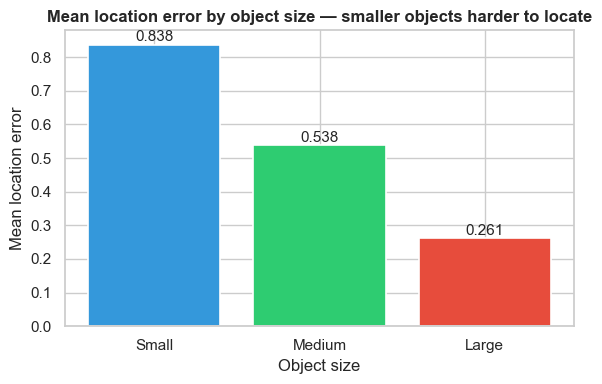

In [66]:
# Location error by object size (lower is better)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(means_by_size.index, means_by_size["Location error"], color=colors, edgecolor="white", linewidth=1.2)
ax.set_xlabel("Object size")
ax.set_ylabel("Mean location error")
ax.set_title("Mean location error by object size — smaller objects harder to locate", fontweight="bold")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()